<a href="https://colab.research.google.com/github/Shubhangi7779/Python-Mini-Project/blob/main/E-Commerce_Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# 1. Sample E-Commerce Churn Dataset
data = {
    "Age": [18, 25, 45, 32, 50, 23, 40, 29, 55, 35],
    "Tenure": [1, 5, 12, 3, 20, 2, 8, 4, 15, 6],
    "UsageHours": [5, 15, 45, 10, 50, 8, 30, 12, 60, 22],
    "SupportCalls": [4, 1, 0, 3, 0, 5, 1, 2, 0, 2],
    "Churn": [1, 0, 0, 1, 0, 1, 0, 1, 0, 0],
}

df = pd.DataFrame(data)

# 2. Features and Target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Standard Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Model Training (Random Forest)
model = RandomForestClassifier(random_state=42)
model.fit(X_train_scaled, y_train)

# 6. Prediction
y_pred = model.predict(X_test_scaled)

print("--- Project Execution Successful ---")
print("Accuracy Score:", accuracy_score(y_test, y_pred))

--- Project Execution Successful ---
Accuracy Score: 0.5


In [3]:
import numpy as np

# Define customer details: [Age, Tenure, UsageHours, SupportCalls]
# Example: Young user, low usage, high support calls
new_customer = np.array([[22, 1, 5, 5]])

# Scale the feature values
new_customer_scaled = scaler.transform(new_customer)

# Make prediction
prediction = model.predict(new_customer_scaled)
probability = model.predict_proba(new_customer_scaled)

print("--- PREDICTION RESULT ---")
if prediction[0] == 1:
    print("Result: Customer is likely to CHURN!")
else:
    print("Result: Customer is SAFE (Will stay).")

print(f"Churn Probability: {probability[0][1] * 100:.1f}%")

--- PREDICTION RESULT ---
Result: Customer is likely to CHURN!
Churn Probability: 100.0%


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


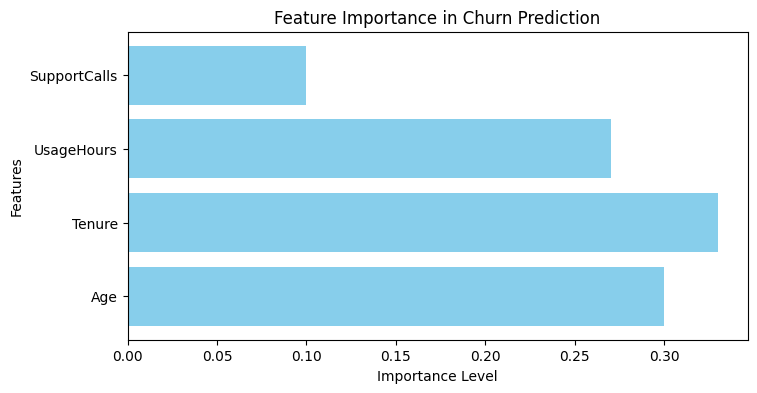

In [4]:
import matplotlib.pyplot as plt

# Get feature importance values from the trained Random Forest model
importances = model.feature_importances_
features = X.columns

# Plot Feature Importances
plt.figure(figsize=(8, 4))
plt.barh(features, importances, color="skyblue")
plt.xlabel("Importance Level")
plt.ylabel("Features")
plt.title("Feature Importance in Churn Prediction")
plt.show()